In [1]:
import cnsplots as cns
cns.setup_matplotlib()
df = sns.load_dataset("iris")

Text(0, 0.5, 'ylabel')

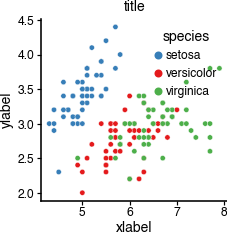

In [2]:
cns.figure(120, 120)
sns.scatterplot(data=df, x="sepal_length", y="sepal_width", s=7, hue='species')
plt.title('title')
plt.xlabel('xlabel')
plt.ylabel('ylabel')
# plt.savefig('../../../Desktop/salam.pdf')

Text(0, 0.5, 'ylabel')

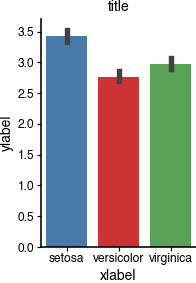

In [24]:
cns.figure(150, 100)
sns.barplot(data=df, x="species", y="sepal_width")
plt.title('title')
plt.xlabel('xlabel')
plt.ylabel('ylabel')
# plt.savefig('../../../Desktop/salam.pdf')

In [10]:
# adata = sc.datasets.krumsiek11()
# sc.pl.heatmap(adata, adata.var_names, 'cell_type', dendrogram=True)
# plt.savefig('../../../Desktop/salam.pdf')

# adata = sc.datasets.pbmc68k_reduced()
# sc.pl.umap(adata, color="HES4")

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
         122.25 <0.005     91.99

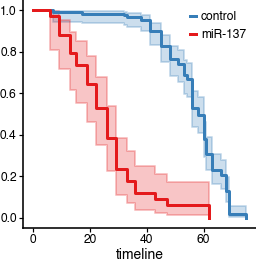

In [3]:
ax = cns.figure(150, 150)
from lifelines.datasets import load_waltons
df = load_waltons()
T = df['T']
E = df['E']
groups = df['group']

from lifelines import KaplanMeierFitter
kmf = KaplanMeierFitter()
ix = (groups == 'miR-137')

kmf.fit(T[~ix], E[~ix], label='control')
ax = kmf.plot_survival_function(ax=ax)

kmf.fit(T[ix], E[ix], label='miR-137')
ax = kmf.plot_survival_function(ax=ax)
plt.savefig('../../../Desktop/salam.pdf')

from lifelines.statistics import logrank_test
logrank_test(T[ix], T[~ix], event_observed_A=E[ix], event_observed_B=E[~ix]).print_summary()

In [ ]:
import scipy as sp
import seaborn as sns

import dotfiles as dfs


def test_barplot(self):
    df = sns.load_dataset("iris")
    ax = dfs.pl.get_ax((150, 150))
    dfs.pl.set_x(ax, rotation=90)
    g = sns.barplot(data=df, x="species", y="sepal_width", **dfs.pl.barplot())

    # adding values to the bars
    groupedvalues = df.groupby("species").mean().reset_index()
    for _, row in groupedvalues.iterrows():
        g.text(
            row.name,
            row["sepal_width"],
            round(row["sepal_width"], 2),
            color="black",
            ha="center",
            rotation=90,
            size=7,
        )


def test_scatterplot(self):
    df = sns.load_dataset("iris")
    dfs.pl.get_ax((150, 150))
    sns.scatterplot(data=df, x="sepal_length", y="sepal_width", s=8)


def test_histplot(self):
    df = sns.load_dataset("iris")
    dfs.pl.get_ax((150, 150))
    sns.histplot(data=df, x="sepal_width")


def test_boxstripplot(self):
    df = sns.load_dataset("iris")
    dfs.pl.get_ax((150, 150))
    sns.boxplot(
        data=df,
        x="species",
        y="sepal_width",
        width=0.5,
        showfliers=False,
        # **dfs.pl.boxplot()
    )
    sns.stripplot(data=df, x="species", y="sepal_width", size=3, linewidth=0)


def test_regplot(sef):
    df = sns.load_dataset("iris")
    dfs.pl.get_ax((150, 150))
    r, p = sp.stats.pearsonr(df["sepal_length"], df["sepal_width"])
    g = sns.regplot(data=df, x="sepal_length", y="sepal_width", **dfs.pl.regplot())
    g.text(6, 4.5, rf"$\rho$={r:.2f}, $P$={p:.2g}")


def barplot(df, x, y):
    args = {
        "edgecolor": "black",
        "linewidth": 1,
        "ci": None,
        # palette=data.set_index(x)[color].to_dict() if color is not None else None,
    }
    g = sns.barplot(data=df, x=x, y=y, **args)

    # adding values to the bars
    groupedvalues = df.groupby(x).mean().reset_index()
    for _, row in groupedvalues.iterrows():
        g.text(
            row.name,
            row[y] + 0.05,
            round(row[y], 2),
            color="black",
            ha="center",
            rotation=0,
            size=6,
        )


def distplot(color="#272822"):
    args = {"hist_kws": {"width": 0.5, "alpha": 1.0, "color": color}}
    return args


def boxplot():
    args = {
        "boxprops": {"facecolor": "white", "edgecolor": "orange"},
        "medianprops": {"color": "red"},
        "whiskerprops": {"color": "blue"},
        "capprops": {"color": "green"},
        "flierprops": {
            "markerfacecolor": "purple",
            "markersize": 3,
            "markeredgecolor": "purple",
            "marker": "o",
            "linewidth": 0,
        },
    }
    return args


def regplot():
    args = {
        "line_kws": {"color": "blue", "lw": 3},
        "scatter_kws": {"s": 3, "color": "black", "edgecolor": "black", "alpha": 1},
    }
    return args
